# Lofted Surface Voronoi Generation

This notebook builds a lofted surface from 8 circles defined by radii in `data/lofted_surface_inputs.json`. Each circle is created on the `XY` plane around the origin and then translated along `Z` in fixed `12` unit increments: `0, 12, 24, ...`.

The loft is sliced by the `YZ` plane through the origin, one side is kept, a padded bounding box is filled with random points from `data/voronoi_points_inputs.json`, a bounded 3D Voronoi diagram is generated, and the cells are intersected with the kept half of the loft.

All intersection curves that hit the kept shape are retained. Closed curves stay closed, and open curves are closed by connecting their endpoints with one straight segment. Only cells with no intersection at all are discarded. The final output is shown as a shaded static render so it remains visible even when notebook widget rendering is unreliable.

In [1]:
import colorsys
import tempfile
from dataclasses import replace
from pathlib import Path
from uuid import uuid4

import ipywidgets as widgets
import numpy as np
import pyvista as pv
from IPython.display import Image, Markdown, display

from compass_web.lofted_surface_voronoi import (
    _fan_surface_from_center,
    _loft_between_polylines,
    _scale_and_offset_polyline,
    analyze_and_generate_surfaces,
    build_bounded_voronoi_cells,
    build_lofted_surface,
    build_polyline_mesh,
    clip_surface_in_half,
    intersect_cells_with_surface,
    load_generation_config,
    load_voronoi_point_config,
    pad_bounds,
    random_points_in_bounds,
)

pv.set_plot_theme("document")

MAX_MODEL_SPAN = 150.0
MIN_RADIUS = 5.0
MAX_RADIUS = 70.0
MAX_Z_INCREMENT = MAX_MODEL_SPAN / 7.0

surface_config_path = Path("data/lofted_surface_inputs.json")
point_config_path = Path("data/voronoi_points_inputs.json")
surface_config = load_generation_config(surface_config_path)
point_config = load_voronoi_point_config(point_config_path)


def make_float_control(
    *,
    value: float,
    min_value: float,
    max_value: float,
    step: float,
    description: str,
    readout_format: str,
    slider_width: str = "440px",
    input_width: str = "100px",
) -> tuple[widgets.HBox, widgets.FloatSlider, widgets.BoundedFloatText]:
    slider = widgets.FloatSlider(
        value=value,
        min=min_value,
        max=max_value,
        step=step,
        description=description,
        continuous_update=False,
        readout=False,
        layout=widgets.Layout(width=slider_width),
        style={"description_width": "70px"},
    )
    # The bounded text box gives a direct click-and-type way to enter exact values.
    text = widgets.BoundedFloatText(
        value=value,
        min=min_value,
        max=max_value,
        step=step,
        layout=widgets.Layout(width=input_width),
    )
    widgets.jslink((slider, "value"), (text, "value"))
    row = widgets.HBox([slider, text])
    return row, slider, text


def make_int_control(
    *,
    value: int,
    min_value: int,
    max_value: int,
    step: int,
    description: str,
    slider_width: str = "440px",
    input_width: str = "100px",
) -> tuple[widgets.HBox, widgets.IntSlider, widgets.BoundedIntText]:
    slider = widgets.IntSlider(
        value=value,
        min=min_value,
        max=max_value,
        step=step,
        description=description,
        continuous_update=False,
        readout=False,
        layout=widgets.Layout(width=slider_width),
        style={"description_width": "70px"},
    )
    text = widgets.BoundedIntText(
        value=value,
        min=min_value,
        max=max_value,
        step=step,
        layout=widgets.Layout(width=input_width),
    )
    widgets.jslink((slider, "value"), (text, "value"))
    row = widgets.HBox([slider, text])
    return row, slider, text


radius_controls = [
    make_float_control(
        value=float(radius),
        min_value=MIN_RADIUS,
        max_value=MAX_RADIUS,
        step=0.001,
        description=f"R{i + 1}",
        readout_format=".3f",
    )
    for i, radius in enumerate(surface_config.radii)
]
radius_rows = [row for row, _, _ in radius_controls]
radius_sliders = [slider for _, slider, _ in radius_controls]

spacing_row, spacing_slider, _ = make_float_control(
    value=float(surface_config.z_increment),
    min_value=4.0,
    max_value=MAX_Z_INCREMENT,
    step=0.01,
    description="Spacing",
    readout_format=".2f",
)
point_count_row, point_count_slider, _ = make_int_control(
    value=int(point_config.seed_count),
    min_value=2,
    max_value=300,
    step=1,
    description="Points",
)
seed_row, seed_slider, _ = make_int_control(
    value=int(point_config.random_seed),
    min_value=0,
    max_value=9999,
    step=1,
    description="Seed",
)
extrusion_row, extrusion_multiplier_slider, _ = make_float_control(
    value=0.5,
    min_value=0.0,
    max_value=3.0,
    step=0.05,
    description="Extrude",
    readout_format=".2f",
)


def validate_geometry_limits(radii: tuple[float, ...], z_increment: float) -> tuple[float, float]:
    max_width = 2.0 * max(radii)
    max_height = z_increment * (len(radii) - 1)
    if max_width > MAX_MODEL_SPAN + 1e-9:
        raise ValueError(
            f"The widest circle would produce {max_width:.2f} units in width, which is above the {MAX_MODEL_SPAN:.0f} unit limit."
        )
    if max_height > MAX_MODEL_SPAN + 1e-9:
        raise ValueError(
            f"The stacked circles would span {max_height:.2f} units in Z, which is above the {MAX_MODEL_SPAN:.0f} unit limit."
        )
    return max_width, max_height


def get_active_surface_config():
    radii = tuple(float(slider.value) for slider in radius_sliders)
    z_increment = float(spacing_slider.value)
    validate_geometry_limits(radii, z_increment)
    z_levels = tuple(index * z_increment for index in range(len(radii)))
    return replace(surface_config, radii=radii, z_increment=z_increment, z_levels=z_levels)


def get_active_point_config():
    return replace(
        point_config,
        seed_count=int(point_count_slider.value),
        random_seed=int(seed_slider.value),
    )


def get_extrusion_multiplier() -> float:
    return float(extrusion_multiplier_slider.value)


display(
    Markdown(
        "### Geometry Controls\n\n"
        "These controls override the JSON defaults for this notebook run only. "
        "Every slider also has a bounded number field on the right so you can click and type exact values.\n\n"
        f"Design guardrails: total width must stay at or below {MAX_MODEL_SPAN:.0f} units and total Z height must also stay at or below {MAX_MODEL_SPAN:.0f} units. "
        "Width here is `2 * max(radius)`, and height is `7 * spacing` because the loft uses 8 circles."
    )
)
display(
    widgets.VBox(
        [
            *radius_rows,
            spacing_row,
            point_count_row,
            seed_row,
            extrusion_row,
        ]
    )
)
(surface_config, point_config)


### Geometry Controls

These controls override the JSON defaults for this notebook run only. Every slider also has a bounded number field on the right so you can click and type exact values.

Design guardrails: total width must stay at or below 150 units and total Z height must also stay at or below 150 units. Width here is `2 * max(radius)`, and height is `7 * spacing` because the loft uses 8 circles.

(LoftedVoronoiConfig(radii=(8.91, 10.446, 10.46, 17.66, 11.26, 19.299, 11.26, 14.46), z_levels=(0.0, 13.38, 26.76, 40.14, 53.52, 66.9, 80.28, 93.66000000000001), z_increment=13.38, circle_resolution=120, slice_normal=(1.0, 0.0, 0.0), slice_origin=(0.0, 0.0, 0.0), bbox_padding=4.0, line_tolerance=0.001),
 VoronoiPointConfig(seed_count=78, random_seed=12))

In [2]:
# Read the latest widget values once so every downstream cell works from the same inputs.
active_surface_config = get_active_surface_config()
active_point_config = get_active_point_config()
extrusion_multiplier = get_extrusion_multiplier()

# The widest section controls the total width because all circles are centered on the origin.
current_width = 2.0 * max(active_surface_config.radii)
current_height = active_surface_config.z_levels[-1] - active_surface_config.z_levels[0]

# Build the full loft first, then clip it in half along the YZ plane.
full_surface = build_lofted_surface(active_surface_config)
half_surface = clip_surface_in_half(
    full_surface,
    normal=active_surface_config.slice_normal,
    origin=active_surface_config.slice_origin,
)

# A slightly larger box is used later so the Voronoi cells stay finite before intersection.
padded_bounds = pad_bounds(half_surface.bounds, active_surface_config.bbox_padding)

print(f"Radii: {list(active_surface_config.radii)}")
print(f"Z positions: {list(active_surface_config.z_levels)}")
print(f"Current width: {current_width:.2f} / {MAX_MODEL_SPAN:.0f}")
print(f"Current height: {current_height:.2f} / {MAX_MODEL_SPAN:.0f}")
print(f"Slice plane: YZ at x = {active_surface_config.slice_origin[0]}")
print(f"Voronoi seed points: {active_point_config.seed_count}")
print(f"Voronoi random seed: {active_point_config.random_seed}")
print(f"Extrusion multiplier: {extrusion_multiplier:.2f}")
print(f"Full loft surface: {full_surface.n_points} points / {full_surface.n_cells} cells")
print(f"Kept half surface: {half_surface.n_points} points / {half_surface.n_cells} cells")
print(f"Padded bounds: {padded_bounds}")


Radii: [8.91, 10.446, 10.46, 17.66, 11.26, 19.299, 11.26, 14.46]
Z positions: [0.0, 13.38, 26.76, 40.14, 53.52, 66.9, 80.28, 93.66000000000001]
Current width: 38.60 / 150
Current height: 93.66 / 150
Slice plane: YZ at x = 0.0
Voronoi seed points: 78
Voronoi random seed: 12
Extrusion multiplier: 0.50
Full loft surface: 960 points / 1680 cells
Kept half surface: 510 points / 868 cells
Padded bounds: (-4.0, 23.299, -23.299, 23.299, -4.0, 97.66000000000001)


In [3]:
# Fill the padded box with random points. These points are the seeds that define the Voronoi cells.
seed_points = random_points_in_bounds(
    bounds=padded_bounds,
    count=active_point_config.seed_count,
    seed=active_point_config.random_seed,
)

# Build finite Voronoi cells inside the padded box, then intersect them with the clipped loft.
voronoi_cells = build_bounded_voronoi_cells(seed_points, padded_bounds)
closed_polylines = intersect_cells_with_surface(
    surface=half_surface,
    cells=voronoi_cells,
    tolerance=active_surface_config.line_tolerance,
)
polyline_mesh = build_polyline_mesh(closed_polylines)

print(f"Random seed points: {len(seed_points)}")
print(f"Voronoi random seed: {active_point_config.random_seed}")
print(f"Bounded Voronoi cells: {len(voronoi_cells)}")
print(f"Surface intersection polylines kept: {len(closed_polylines)}")
print(f"Polyline mesh lines: {polyline_mesh.n_lines}")


Random seed points: 78
Voronoi random seed: 12
Bounded Voronoi cells: 78
Surface intersection polylines kept: 52
Polyline mesh lines: 52


In [4]:
# Analyze each retained curve and generate the derived surface patches.
curve_result = analyze_and_generate_surfaces(
    closed_polylines,
    loft_bounds=half_surface.bounds,
    tolerance=active_surface_config.line_tolerance,
    extrusion_multiplier=extrusion_multiplier,
)
analysis_original_polylines = [analysis.original_polyline for analysis in curve_result.analyses]
analysis_followup_polylines = [analysis.followup_polyline for analysis in curve_result.analyses]
followup_polyline_mesh = build_polyline_mesh(list(curve_result.followup_polylines))
bbox_edge_meshes = [analysis.bbox_mesh.extract_all_edges() for analysis in curve_result.analyses]
circle_centers = np.array([analysis.circle_center for analysis in curve_result.analyses], dtype=float)
curve_lengths = np.array([analysis.curve_length for analysis in curve_result.analyses], dtype=float)
bbox_volumes = np.array([analysis.bbox_volume for analysis in curve_result.analyses], dtype=float)
ratios = np.array([analysis.ratio for analysis in curve_result.analyses], dtype=float)
sorted_indices = np.argsort(ratios)[::-1]
large_curve_count = sum(analysis.ratio >= curve_result.average_ratio for analysis in curve_result.analyses)
small_curve_count = len(curve_result.analyses) - large_curve_count
discontinuity_point_sets = [analysis.discontinuity_points for analysis in curve_result.analyses]
all_discontinuity_points = (
    np.vstack([points for points in discontinuity_point_sets if len(points) > 0])
    if any(len(points) > 0 for points in discontinuity_point_sets)
    else np.zeros((0, 3), dtype=float)
)
curve_colors = [
    "#%02x%02x%02x" % tuple(int(channel * 255) for channel in colorsys.hsv_to_rgb(index / len(curve_result.analyses), 0.7, 1.0))
    for index in range(len(curve_result.analyses))
] if curve_result.analyses else []
curve_label_points = np.array([
    analysis.followup_polyline[:-1].mean(axis=0) for analysis in curve_result.analyses
], dtype=float) if curve_result.analyses else np.zeros((0, 3), dtype=float)
curve_labels = [f"crv {index + 1}" for index in range(len(curve_result.analyses))]
analysis_output_meshes: list[pv.PolyData] = []
analysis_preview_output_meshes: list[pv.PolyData] = []
analysis_output_modes: list[str] = []
for analysis in curve_result.analyses:
    ratio_factor = analysis.ratio / curve_result.average_ratio if curve_result.average_ratio > active_surface_config.line_tolerance else 1.0
    offset_distance = extrusion_multiplier * ratio_factor
    offset_vector = analysis.offset_direction * offset_distance
    if analysis.ratio >= curve_result.average_ratio:
        # Large curves become lofted side walls plus a cap.
        moved_scaled_polyline = _scale_and_offset_polyline(
            analysis.followup_polyline,
            center=analysis.circle_center,
            plane_u=analysis.plane_u,
            plane_v=analysis.plane_v,
            scale_factor=0.5,
            offset_vector=offset_vector,
        )
        moved_center = analysis.circle_center + offset_vector
        side_mesh = _loft_between_polylines(analysis.followup_polyline, moved_scaled_polyline)
        cap_mesh = _fan_surface_from_center(moved_center, moved_scaled_polyline[:-1])
        analysis_preview_output_meshes.append(side_mesh)
        analysis_output_meshes.append(side_mesh.merge(cap_mesh).clean().triangulate())
        analysis_output_modes.append("large")
    else:
        # Small curves collapse to a fan so they become simpler accent features.
        moved_center = analysis.circle_center + offset_vector
        fan_mesh = _fan_surface_from_center(moved_center, analysis.discontinuity_points)
        analysis_preview_output_meshes.append(fan_mesh)
        analysis_output_meshes.append(fan_mesh)
        analysis_output_modes.append("small")

generated_surface = curve_result.generated_surface if curve_result.generated_surface.n_points else half_surface
generated_bounds = generated_surface.bounds if generated_surface.n_points else half_surface.bounds
generated_target = generated_surface.center if generated_surface.n_points else half_surface.center

print(f"Analyzed curves: {len(curve_result.analyses)}")
print(f"Average volume/length ratio: {curve_result.average_ratio:.4f}")
print(f"Extrusion multiplier used: {extrusion_multiplier:.2f}")
print(f"Curves classified as large: {large_curve_count}")
print(f"Curves classified as small: {small_curve_count}")
print(f"Generated surface faces: {curve_result.generated_surface.n_cells}")
print(f"Large-curve loft faces: {curve_result.larger_surface.n_cells}")
print(f"Small-curve fan faces: {curve_result.smaller_surface.n_cells}")
if curve_result.followup_polylines:
    print(
        f"Follow-up curve segments - min: {min(len(polyline) - 1 for polyline in curve_result.followup_polylines)}, "
        f"max: {max(len(polyline) - 1 for polyline in curve_result.followup_polylines)}, "
        f"mean: {np.mean([len(polyline) - 1 for polyline in curve_result.followup_polylines]):.1f}"
    )
else:
    print("Follow-up curve segments: no retained curves were generated.")
print(f"Discontinuity markers total: {len(all_discontinuity_points)}")

top_count = min(8, len(sorted_indices))
summary_rows = [
    (
        int(index),
        float(ratios[index]),
        float(bbox_volumes[index]),
        float(curve_lengths[index]),
    )
    for index in sorted_indices[:top_count]
]
summary_rows


Analyzed curves: 52
Average volume/length ratio: 7.5369
Extrusion multiplier used: 0.50
Curves classified as large: 21
Curves classified as small: 31
Generated surface faces: 4459
Large-curve loft faces: 4064
Small-curve fan faces: 395
Follow-up curve segments - min: 3, max: 173, mean: 65.0
Discontinuity markers total: 937


[(42, 32.03911410509613, 2016.1676929369112, 62.928322122871066),
 (9, 26.15950174477769, 1470.1174705687713, 56.198221392433666),
 (21, 23.805503230294672, 1375.2929553178667, 57.77205976337778),
 (38, 22.09317920280552, 1184.9155162401944, 53.6326395292954),
 (16, 21.85239027325271, 1058.8114317713737, 48.45288860996397),
 (31, 21.630582201285765, 1137.2296716008532, 52.575083787308046),
 (11, 20.321693147261193, 1041.4238798858323, 51.24690508508085),
 (26, 18.897145206864295, 983.8834761960666, 52.06519108710007)]

In [5]:
def distinct_colors(count: int) -> list[str]:
    if count <= 0:
        return []
    return [
        "#%02x%02x%02x" % tuple(int(channel * 255) for channel in colorsys.hsv_to_rgb(index / count, 0.7, 1.0))
        for index in range(count)
    ]


def camera_position_from_bounds(
    bounds: tuple[float, float, float, float, float, float],
    target: np.ndarray | list[float] | tuple[float, float, float],
) -> list[list[float]]:
    xmin, xmax, ymin, ymax, zmin, zmax = bounds
    max_span = max(xmax - xmin, ymax - ymin, zmax - zmin, 1.0)
    target_array = np.asarray(target, dtype=float)
    # This keeps a readable three-quarter view while allowing the fitted bounds to control the final framing.
    camera_position = target_array + np.array([1.05 * max_span, -1.45 * max_span, 0.78 * max_span], dtype=float)
    return [camera_position.tolist(), target_array.tolist(), [0.0, 0.0, 1.0]]


def merge_bounds(bounds_list: list[tuple[float, float, float, float, float, float]]) -> tuple[float, float, float, float, float, float]:
    if not bounds_list:
        raise ValueError("bounds_list must not be empty.")
    mins = np.array([[bounds[0], bounds[2], bounds[4]] for bounds in bounds_list], dtype=float)
    maxs = np.array([[bounds[1], bounds[3], bounds[5]] for bounds in bounds_list], dtype=float)
    min_corner = mins.min(axis=0)
    max_corner = maxs.max(axis=0)
    return (
        float(min_corner[0]),
        float(max_corner[0]),
        float(min_corner[1]),
        float(max_corner[1]),
        float(min_corner[2]),
        float(max_corner[2]),
    )


def bounds_from_points(points: np.ndarray) -> tuple[float, float, float, float, float, float] | None:
    if len(points) == 0:
        return None
    points_array = np.asarray(points, dtype=float)
    min_corner = points_array.min(axis=0)
    max_corner = points_array.max(axis=0)
    return (
        float(min_corner[0]),
        float(max_corner[0]),
        float(min_corner[1]),
        float(max_corner[1]),
        float(min_corner[2]),
        float(max_corner[2]),
    )


def padded_scene_bounds(
    bounds: tuple[float, float, float, float, float, float],
    padding_fraction: float = 0.22,
    min_padding: float = 1.0,
) -> tuple[float, float, float, float, float, float]:
    xmin, xmax, ymin, ymax, zmin, zmax = bounds
    spans = np.array([xmax - xmin, ymax - ymin, zmax - zmin], dtype=float)
    padding = np.maximum(spans * padding_fraction, min_padding)
    return (
        float(xmin - padding[0]),
        float(xmax + padding[0]),
        float(ymin - padding[1]),
        float(ymax + padding[1]),
        float(zmin - padding[2]),
        float(zmax + padding[2]),
    )


def center_from_bounds(bounds: tuple[float, float, float, float, float, float]) -> np.ndarray:
    return np.array(
        [
            0.5 * (bounds[0] + bounds[1]),
            0.5 * (bounds[2] + bounds[3]),
            0.5 * (bounds[4] + bounds[5]),
        ],
        dtype=float,
    )


def render_static_scene(
    *,
    title: str,
    bounds: tuple[float, float, float, float, float, float],
    target: np.ndarray | list[float] | tuple[float, float, float],
    meshes: list[tuple[pv.DataSet, dict[str, object]]] | None = None,
    line_meshes: list[tuple[pv.PolyData, dict[str, object]]] | None = None,
    point_sets: list[tuple[np.ndarray, dict[str, object]]] | None = None,
    label_sets: list[tuple[np.ndarray, list[str], dict[str, object]]] | None = None,
    fit_bounds: tuple[float, float, float, float, float, float] | None = None,
    fit_target: np.ndarray | list[float] | tuple[float, float, float] | None = None,
    zoom_factor: float = 1.1,
    window_size: tuple[int, int] = (1100, 820),
) -> bytes:
    plotter = pv.Plotter(off_screen=True, window_size=window_size)
    plotter.set_background("#1a1a2e")

    for mesh, kwargs in meshes or []:
        if mesh.n_points == 0:
            continue
        plotter.add_mesh(mesh, **kwargs)

    for line_mesh, kwargs in line_meshes or []:
        if line_mesh.n_points == 0:
            continue
        plotter.add_mesh(line_mesh, render_lines_as_tubes=True, **kwargs)

    for points, kwargs in point_sets or []:
        if len(points) == 0:
            continue
        plotter.add_points(np.asarray(points, dtype=float), **kwargs)

    for points, labels, kwargs in label_sets or []:
        if len(points) == 0 or not labels:
            continue
        plotter.add_point_labels(np.asarray(points, dtype=float), labels, **kwargs)

    plotter.add_axes()
    camera_bounds = fit_bounds if fit_bounds is not None else bounds
    camera_target = np.asarray(fit_target if fit_target is not None else target, dtype=float)
    plotter.camera_position = camera_position_from_bounds(camera_bounds, camera_target)
    # Static images have no orbit controls, so a mild zoom helps the fitted scene occupy more of the screenshot.
    plotter.camera.zoom(zoom_factor)
    plotter.add_text(title, position="upper_left", font_size=12, color="white")

    image_path = Path(tempfile.gettempdir()) / f"{uuid4().hex}.png"
    try:
        plotter.screenshot(str(image_path))
        return image_path.read_bytes()
    finally:
        plotter.close()
        image_path.unlink(missing_ok=True)


def display_static_scene(**kwargs: object) -> None:
    display(Image(data=render_static_scene(**kwargs)))


def selected_curve_indices(curve_index: int, curve_count: int, show_all_up_to: bool) -> list[int]:
    if curve_index <= 0:
        return []
    if show_all_up_to:
        return list(range(min(curve_index, curve_count)))
    return [min(curve_index, curve_count) - 1]


def build_selected_discontinuity_points(indices: list[int]) -> np.ndarray:
    selected_sets = [discontinuity_point_sets[index] for index in indices if len(discontinuity_point_sets[index]) > 0]
    if not selected_sets:
        return np.zeros((0, 3), dtype=float)
    return np.vstack(selected_sets)


def build_selected_centers(indices: list[int]) -> np.ndarray:
    if not indices:
        return np.zeros((0, 3), dtype=float)
    return circle_centers[indices]


def build_selected_curve_label_points(indices: list[int]) -> np.ndarray:
    if not indices:
        return np.zeros((0, 3), dtype=float)
    return curve_label_points[indices]


def build_selected_curve_labels(indices: list[int]) -> list[str]:
    return [curve_labels[index] for index in indices]


def build_selected_curve_layers(indices: list[int]) -> list[tuple[pv.PolyData, dict[str, object]]]:
    return [
        (
            build_polyline_mesh([analysis_followup_polylines[index]]),
            {
                "color": curve_colors[index],
                "line_width": 3,
                "opacity": 1.0,
            },
        )
        for index in indices
    ]


def build_selected_output_layers(indices: list[int]) -> list[tuple[pv.PolyData, dict[str, object]]]:
    return [
        (
            analysis_preview_output_meshes[index],
            {
                "color": curve_colors[index],
                "opacity": 1.0,
                "smooth_shading": True,
            },
        )
        for index in indices
        if analysis_preview_output_meshes[index].n_points > 0
    ]


def selected_curve_view_fit(indices: list[int]) -> tuple[tuple[float, float, float, float, float, float], np.ndarray]:
    if not indices:
        return padded_scene_bounds(half_surface.bounds, padding_fraction=0.08), np.asarray(half_surface.center, dtype=float)
    fit_bounds_list = [
        build_polyline_mesh([analysis_followup_polylines[index]]).bounds
        for index in indices
        if len(analysis_followup_polylines[index]) > 0
    ]
    point_bounds = bounds_from_points(build_selected_discontinuity_points(indices))
    label_bounds = bounds_from_points(build_selected_curve_label_points(indices))
    if point_bounds is not None:
        fit_bounds_list.append(point_bounds)
    if label_bounds is not None:
        fit_bounds_list.append(label_bounds)
    merged = merge_bounds(fit_bounds_list) if fit_bounds_list else half_surface.bounds
    padded = padded_scene_bounds(merged, padding_fraction=0.3, min_padding=1.5)
    return padded, center_from_bounds(padded)


def selected_output_view_fit(indices: list[int], show_final: bool) -> tuple[tuple[float, float, float, float, float, float], np.ndarray]:
    if not indices:
        return padded_scene_bounds(generated_bounds, padding_fraction=0.08), np.asarray(generated_target, dtype=float)
    selected_meshes = (
        [analysis_output_meshes[index] for index in indices if analysis_output_meshes[index].n_points > 0]
        if show_final
        else [analysis_preview_output_meshes[index] for index in indices if analysis_preview_output_meshes[index].n_points > 0]
    )
    fit_bounds_list = [mesh.bounds for mesh in selected_meshes]
    center_bounds = bounds_from_points(build_selected_centers(indices))
    label_bounds = bounds_from_points(build_selected_centers(indices))
    if center_bounds is not None:
        fit_bounds_list.append(center_bounds)
    if label_bounds is not None:
        fit_bounds_list.append(label_bounds)
    merged = merge_bounds(fit_bounds_list) if fit_bounds_list else generated_bounds
    padded = padded_scene_bounds(merged, padding_fraction=0.32, min_padding=1.5)
    return padded, center_from_bounds(padded)


def make_curve_subset_browser() -> None:
    curve_row, slider, _ = make_int_control(
        value=0,
        min_value=0,
        max_value=len(analysis_followup_polylines),
        step=1,
        description="Curve",
        slider_width="320px",
        input_width="90px",
    )
    show_all_checkbox = widgets.Checkbox(
        value=True,
        description="Show all from 0 to selected curve",
    )
    show_final_checkbox = widgets.Checkbox(
        value=False,
        description="Show final capped outputs",
    )
    summary = widgets.HTML()
    details = widgets.HTML(layout=widgets.Layout(max_height="180px", overflow="auto"))
    curves_image = widgets.Image(format="png", layout=widgets.Layout(width="540px"))
    outputs_image = widgets.Image(format="png", layout=widgets.Layout(width="540px"))

    def update_view(_: object | None = None) -> None:
        indices = selected_curve_indices(slider.value, len(analysis_followup_polylines), show_all_checkbox.value)
        selected_points = build_selected_discontinuity_points(indices)
        selected_centers = build_selected_centers(indices)
        selected_label_points = build_selected_curve_label_points(indices)
        selected_labels = build_selected_curve_labels(indices)
        selected_modes = [analysis_output_modes[index] for index in indices]
        output_title = "Generated final outputs for the selected curves" if show_final_checkbox.value else "Generated shell outputs for the selected curves"
        curve_layers = build_selected_curve_layers(indices)
        preview_output_layers = build_selected_output_layers(indices)
        final_output_layers = [
            (
                analysis_output_meshes[index],
                {
                    "color": curve_colors[index],
                    "opacity": 1.0,
                    "smooth_shading": True,
                },
            )
            for index in indices
            if analysis_output_meshes[index].n_points > 0
        ]
        curve_fit_bounds, curve_fit_target = selected_curve_view_fit(indices)
        output_fit_bounds, output_fit_target = selected_output_view_fit(indices, show_final_checkbox.value)
        summary.value = (
            f"<b>Selected curves:</b> {len(indices)}"
            f" | <b>Large outputs:</b> {sum(mode == 'large' for mode in selected_modes)}"
            f" | <b>Small outputs:</b> {sum(mode == 'small' for mode in selected_modes)}"
            f" | <b>Output mode:</b> {'final capped' if show_final_checkbox.value else 'shell preview'}"
            " | <b>Curve 0</b> means hide all curves and generated outputs."
        )
        if indices:
            detail_rows = [
                f"<li><b>{curve_labels[index]}</b> | class: {analysis_output_modes[index]} | ratio: {ratios[index]:.2f} | length: {curve_lengths[index]:.2f} | discontinuities: {len(discontinuity_point_sets[index])}</li>"
                for index in indices
            ]
            details.value = "<b>Selected curve info</b><ul>" + "".join(detail_rows) + "</ul>"
        else:
            details.value = "<b>Selected curve info</b><div>No curve selected.</div>"
        curves_image.value = render_static_scene(
            title="Selected retained curves and discontinuity markers",
            bounds=half_surface.bounds,
            target=half_surface.center,
            meshes=[
                (
                    half_surface,
                    {
                        "color": "#727272",
                        "opacity": 0.12,
                        "smooth_shading": True,
                    },
                ),
            ],
            line_meshes=curve_layers,
            point_sets=[
                (
                    selected_points,
                    {
                        "color": "#ff4d4d",
                        "point_size": 13,
                        "render_points_as_spheres": True,
                        "opacity": 1.0,
                    },
                ),
            ],
            label_sets=[
                (
                    selected_label_points,
                    selected_labels,
                    {
                        "shape_opacity": 0.2,
                        "fill_shape": True,
                        "font_size": 16,
                        "text_color": "white",
                        "point_color": "#ffe082",
                        "margin": 4,
                        "show_points": False,
                        "always_visible": True,
                    },
                ),
            ],
            fit_bounds=curve_fit_bounds,
            fit_target=curve_fit_target,
            zoom_factor=1.18,
            window_size=(1000, 760),
        )
        outputs_image.value = render_static_scene(
            title=output_title,
            bounds=generated_bounds,
            target=generated_target,
            meshes=[
                (
                    half_surface,
                    {
                        "color": "#808080",
                        "opacity": 0.08,
                        "smooth_shading": True,
                    },
                ),
                *(preview_output_layers if not show_final_checkbox.value else final_output_layers),
            ],
            point_sets=[
                (
                    selected_centers,
                    {
                        "color": "#ffe082",
                        "point_size": 12,
                        "render_points_as_spheres": True,
                        "opacity": 1.0,
                    },
                ),
            ],
            label_sets=[
                (
                    selected_centers,
                    selected_labels,
                    {
                        "shape_opacity": 0.2,
                        "fill_shape": True,
                        "font_size": 16,
                        "text_color": "white",
                        "point_color": "#ffe082",
                        "margin": 4,
                        "show_points": False,
                        "always_visible": True,
                    },
                ),
            ],
            fit_bounds=output_fit_bounds,
            fit_target=output_fit_target,
            zoom_factor=1.18,
            window_size=(1000, 760),
        )

    slider.observe(update_view, names="value")
    show_all_checkbox.observe(update_view, names="value")
    show_final_checkbox.observe(update_view, names="value")
    update_view()

    display(
        widgets.VBox(
            [
                curve_row,
                widgets.HBox([show_all_checkbox, show_final_checkbox]),
                summary,
                widgets.HBox([curves_image, outputs_image]),
                details,
            ]
        )
    )


def show_step(title: str, explanation: str) -> None:
    display(Markdown(f"### {title}\n\n{explanation}"))


## Geometry Walkthrough

This section keeps the workflow visual and beginner-friendly. The controls at the top now let you either drag or type exact values for the radii, circle spacing, Voronoi point count, Voronoi seed, and extrusion multiplier before rerunning the downstream cells.

1. Build the loft from the 8 circle sections and clip it with the `YZ` plane so the workflow operates on only one side of the shape.
2. Expand that kept half with a padded bounding box and place random seed points inside it so every Voronoi region becomes bounded instead of shooting off to infinity.
3. Show the retained intersection curves with one color per curve so the different cell traces are easy to distinguish and compare.
4. Use the curve browser to reveal either one selected curve or all curves up to the selected index, together with their corresponding generated outputs. The red markers are detected from tangent breaks together with curvature-transition boundaries, not just obvious kinks.
5. Show the final generated surfaces from the full curved-loop follow-up analysis, now using the live extrusion multiplier from the controls.

The size guardrails stay explicit throughout the notebook: total width is `2 * max(radius)` and total height is `7 * spacing`, and both must stay at or below `150` units. The reason for this step-by-step layout is that each later result depends on geometry extracted from the previous one, so seeing the intermediate state makes it much easier to understand why the final surfaces look the way they do.


### Step 1: Loft the circles and clip the shape in half

The eight circular sections are connected into one lofted skin. The blue plane is the YZ slicing plane at x = 0, and the solid orange surface is the kept half. This clip removes the mirrored side so the later Voronoi intersections are easier to interpret and do not duplicate across both halves.

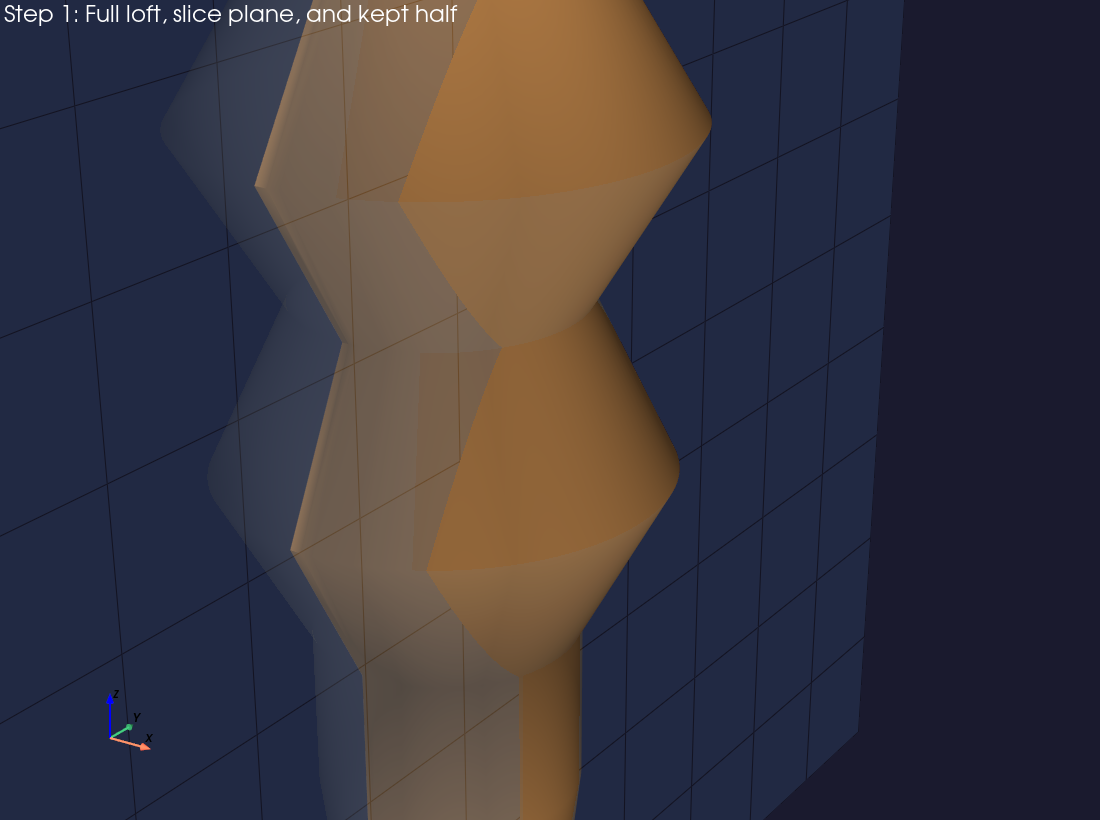

In [6]:
plane_size = 1.15 * max(
    full_surface.bounds[1] - full_surface.bounds[0],
    full_surface.bounds[3] - full_surface.bounds[2],
    full_surface.bounds[5] - full_surface.bounds[4],
)
slice_plane = pv.Plane(
    center=half_surface.center,
    direction=active_surface_config.slice_normal,
    i_size=plane_size,
    j_size=plane_size,
)

show_step(
    "Step 1: Loft the circles and clip the shape in half",
    "The eight circular sections are connected into one lofted skin. The blue plane is the YZ slicing plane at x = 0, and the solid orange surface is the kept half. This clip removes the mirrored side so the later Voronoi intersections are easier to interpret and do not duplicate across both halves.",
)
display_static_scene(
    title="Step 1: Full loft, slice plane, and kept half",
    bounds=full_surface.bounds,
    target=half_surface.center,
    meshes=[
        (
            full_surface,
            {
                "color": "#d9d9d9",
                "opacity": 0.18,
                "smooth_shading": True,
            },
        ),
        (
            slice_plane,
            {
                "color": "#6aa9ff",
                "opacity": 0.25,
                "show_edges": True,
            },
        ),
        (
            half_surface,
            {
                "color": "#ffb366",
                "opacity": 1.0,
                "smooth_shading": True,
            },
        ),
    ],
)


### Step 2: Seed the padded box for the bounded Voronoi construction

The cyan box is slightly larger than the kept loft half, and the yellow points are the random Voronoi seeds inside it. The padding matters because an unconstrained 3D Voronoi diagram would create infinite cells; this box forces every cell to stay finite before we intersect it with the loft.

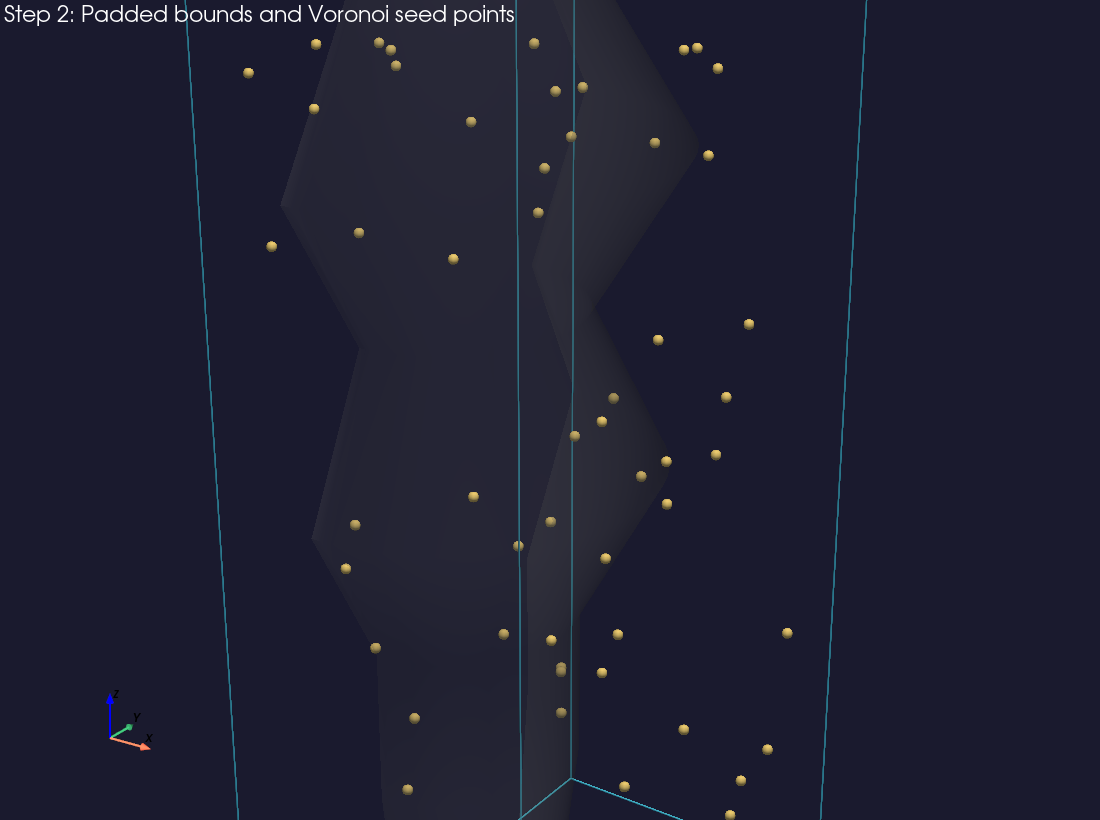

In [7]:
padded_box_edges = pv.Box(bounds=padded_bounds).extract_all_edges()

show_step(
    "Step 2: Seed the padded box for the bounded Voronoi construction",
    "The cyan box is slightly larger than the kept loft half, and the yellow points are the random Voronoi seeds inside it. The padding matters because an unconstrained 3D Voronoi diagram would create infinite cells; this box forces every cell to stay finite before we intersect it with the loft.",
)
display_static_scene(
    title="Step 2: Padded bounds and Voronoi seed points",
    bounds=padded_bounds,
    target=half_surface.center,
    meshes=[
        (
            half_surface,
            {
                "color": "#8c8c8c",
                "opacity": 0.22,
                "smooth_shading": True,
            },
        ),
    ],
    line_meshes=[
        (
            padded_box_edges,
            {
                "color": "#4dd7ff",
                "line_width": 2,
                "opacity": 0.95,
            },
        ),
    ],
    point_sets=[
        (
            seed_points,
            {
                "color": "#ffe082",
                "point_size": 11,
                "render_points_as_spheres": True,
                "opacity": 1.0,
            },
        ),
    ],
)


### Step 3: View every intersection curve as a separate colored trace

Each colored curve is one retained intersection loop coming from a bounded Voronoi cell cutting through the clipped loft. Using one color per loop makes it much easier to see how the cell traces distribute across the surface instead of collapsing into one unreadable line network.

Intersection loops kept: 52


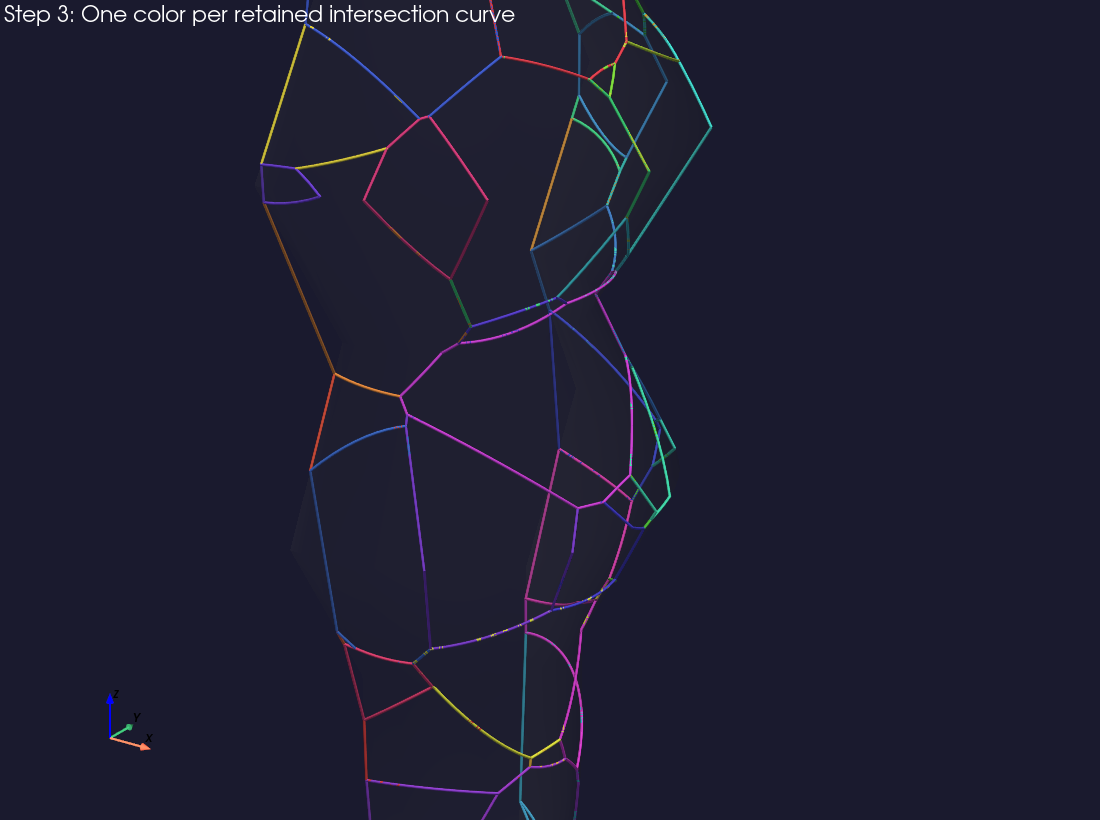

In [8]:
show_step(
    "Step 3: View every intersection curve as a separate colored trace",
    "Each colored curve is one retained intersection loop coming from a bounded Voronoi cell cutting through the clipped loft. Using one color per loop makes it much easier to see how the cell traces distribute across the surface instead of collapsing into one unreadable line network.",
)
print(f"Intersection loops kept: {len(analysis_original_polylines)}")
display_static_scene(
    title="Step 3: One color per retained intersection curve",
    bounds=half_surface.bounds,
    target=half_surface.center,
    meshes=[
        (
            half_surface,
            {
                "color": "#727272",
                "opacity": 0.13,
                "smooth_shading": True,
            },
        ),
    ],
    line_meshes=[
        (
            build_polyline_mesh([polyline]),
            {
                "color": curve_colors[index],
                "line_width": 3,
                "opacity": 1.0,
            },
        )
        for index, polyline in enumerate(analysis_original_polylines)
    ],
)


In [9]:
show_step(
    "Step 4: Optional subset browser",
    "Step 3 already shows the full picture. This browser is only for inspection of subsets. Use the curve control to choose an index from 0 to N. You can drag the slider or click into the numeric field to type the exact curve number you want. With the checkbox enabled, the browser shows all curves from 0 up to the selected value. With it disabled, the browser shows only the corresponding curve. A second checkbox switches the right image between shell preview outputs and final capped outputs.",
)
print(f"Curved loops available in the browser: {len(analysis_followup_polylines)}")
print("Curve value 0 hides all curves and generated outputs.")
make_curve_subset_browser()


### Step 4: Optional subset browser

Step 3 already shows the full picture. This browser is only for inspection of subsets. Use the curve control to choose an index from 0 to N. You can drag the slider or click into the numeric field to type the exact curve number you want. With the checkbox enabled, the browser shows all curves from 0 up to the selected value. With it disabled, the browser shows only the corresponding curve. A second checkbox switches the right image between shell preview outputs and final capped outputs.

Curved loops available in the browser: 52
Curve value 0 hides all curves and generated outputs.


### Step 5: Build the final generated surfaces from the curved-loop follow-up

Curves whose bounding-box-volume to curve-length ratio is at or above the average are treated as larger features and generate lofted patches. Curves below that average generate fan patches. In both cases the output moves outward along the unitized vector from the general loft bounding-box center to the fitted circle center, scaled by the live extrusion multiplier times the cell ratio factor. The faint gray loft half is left in the view as context for where the new surfaces sit.

Average volume/length ratio: 7.5369
Extrusion multiplier: 0.50
Large-curve loft surface faces: 4064
Small-curve fan surface faces: 395


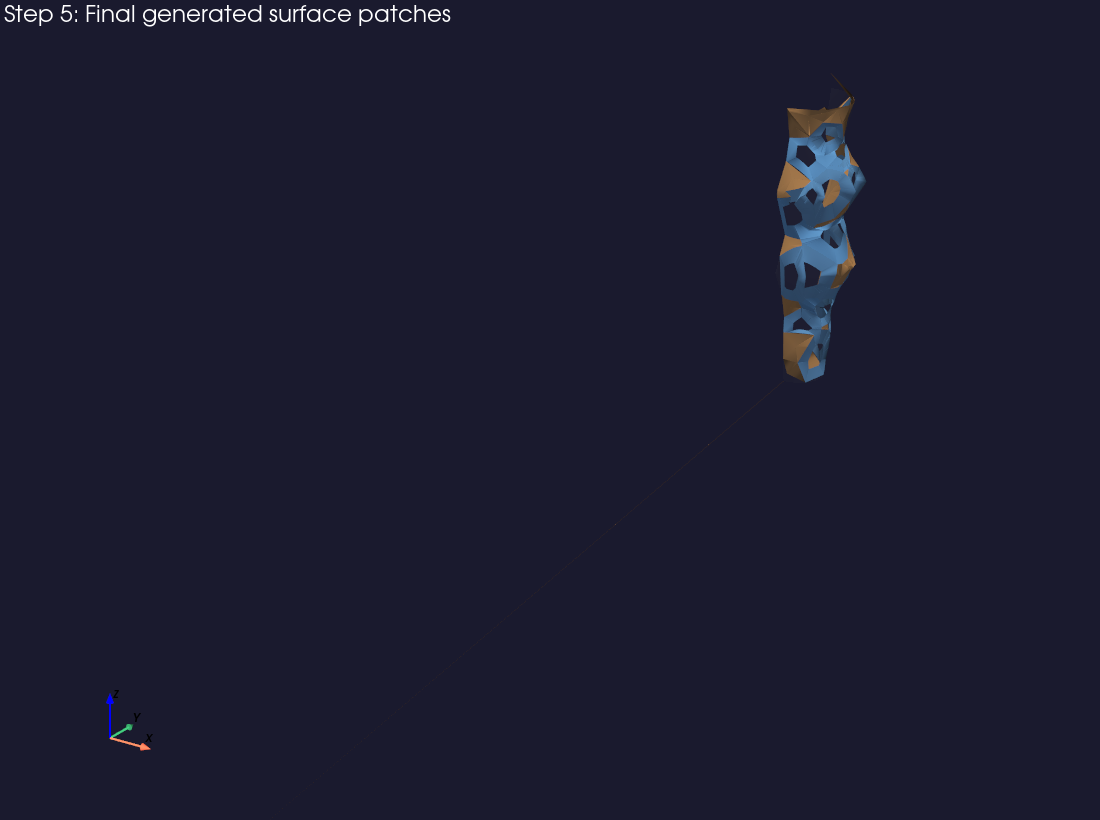

In [10]:
generated_surface = curve_result.generated_surface if curve_result.generated_surface.n_points else half_surface

generated_bounds = generated_surface.bounds if generated_surface.n_points else half_surface.bounds
generated_target = generated_surface.center if generated_surface.n_points else half_surface.center

show_step(
    "Step 5: Build the final generated surfaces from the curved-loop follow-up",
    "Curves whose bounding-box-volume to curve-length ratio is at or above the average are treated as larger features and generate lofted patches. Curves below that average generate fan patches. In both cases the output moves outward along the unitized vector from the general loft bounding-box center to the fitted circle center, scaled by the live extrusion multiplier times the cell ratio factor. The faint gray loft half is left in the view as context for where the new surfaces sit.",
)
print(f"Average volume/length ratio: {curve_result.average_ratio:.4f}")
print(f"Extrusion multiplier: {extrusion_multiplier:.2f}")
print(f"Large-curve loft surface faces: {curve_result.larger_surface.n_cells}")
print(f"Small-curve fan surface faces: {curve_result.smaller_surface.n_cells}")
display_static_scene(
    title="Step 5: Final generated surface patches",
    bounds=generated_bounds,
    target=generated_target,
    meshes=[
        (
            half_surface,
            {
                "color": "#808080",
                "opacity": 0.1,
                "smooth_shading": True,
            },
        ),
        (
            curve_result.larger_surface,
            {
                "color": "#72b7ff",
                "opacity": 1.0,
                "smooth_shading": True,
            },
        ),
        (
            curve_result.smaller_surface,
            {
                "color": "#d9a066",
                "opacity": 1.0,
                "smooth_shading": True,
            },
        ),
    ],
)
